---
## 1. Кітапханалар мен баптаулар

In [1]:
#!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score,  StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.ensemble import (
    ExtraTreesClassifier, GradientBoostingClassifier,
    RandomForestClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.utils import resample
import joblib

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FB',
    'axes.edgecolor':    '#D0D7DE',
    'axes.labelcolor':   '#24292F',
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#24292F',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'text.color':        '#24292F',
    'xtick.color':       '#57606A',
    'ytick.color':       '#57606A',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'grid.color':        '#E6EBF1',
    'grid.linewidth':    0.9,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#D0D7DE',
    'legend.fontsize':   9,
    'figure.dpi':        110,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

STRESS5_COLORS = {1:'#2DA44E', 2:'#54AAB4', 3:'#F0A400', 4:'#E16F24', 5:'#CF222E'}
STRESS3_COLORS = {0:'#2DA44E', 1:'#F0A400', 2:'#CF222E'}
STRESS3_NAMES  = {0:'Low', 1:'Medium', 2:'High'}
MODEL_COLORS  = {
    'Extra Trees':       '#2DA44E',
    'Gradient Boosting': '#0969DA',
    'Random Forest':     '#CF222E',
    'SVM':               '#8250DF',
    'Voting Ensemble':   '#E16F24',
}

print('Кітапханалар жүктелді, ашық тақырып белсендірілді')

Кітапханалар жүктелді, ашық тақырып белсендірілді


---
## 2. Деректерді жүктеу және шолу

In [3]:
df = pd.read_csv('/content/Student Mental health.csv')
df.columns = [
    'timestamp', 'gender', 'age', 'course', 'year', 'cgpa',
    'marital', 'depression', 'anxiety', 'panic_attack', 'treatment'
]

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(20)


Dataset loaded: 101 rows × 11 columns


,timestamp,gender,age,course,year,cgpa,marital,depression,anxiety,panic_attack,treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


In [4]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDescriptive Statistics:')
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     101 non-null    object 
 1   gender        101 non-null    object 
 2   age           100 non-null    float64
 3   course        101 non-null    object 
 4   year          101 non-null    object 
 5   cgpa          101 non-null    object 
 6   marital       101 non-null    object 
 7   depression    101 non-null    object 
 8   anxiety       101 non-null    object 
 9   panic_attack  101 non-null    object 
 10  treatment     101 non-null    object 
dtypes: float64(1), object(10)
memory usage: 8.8+ KB
None

Missing Values:
timestamp       0
gender          0
age             1
course          0
year            0
cgpa            0
marital         0
depression      0
anxiety         0
panic_attack    0
treatment       0
dtype: int64

Descriptive Statistics:
           

---
## 3. Деректерді тазалау

In [5]:
df = df.drop(columns=['timestamp'], errors='ignore')
df['age'] = df['age'].fillna(df['age'].median())
df['year'] = df['year'].str.strip().str.lower().str.replace(' ', '_')

# Normalize course (group rare categories)
top_courses = df['course'].value_counts().nlargest(5).index
df['course_clean'] = df['course'].apply(lambda x: x if x in top_courses else 'Other')

# Encode target: mental health stress level
# 0 = Low  (no conditions: depression=No, anxiety=No, panic=No)
# 1 = Medium (exactly 1 condition)
# 2 = High  (2 or 3 conditions)
df['dep'] = (df['depression'] == 'Yes').astype(int)
df['anx'] = (df['anxiety'] == 'Yes').astype(int)
df['pan'] = (df['panic_attack'] == 'Yes').astype(int)
df['treat'] = (df['treatment'] == 'Yes').astype(int)
df['mental_score'] = df['dep'] + df['anx'] + df['pan']
df['stress_3'] = df['mental_score'].map({0: 0, 1: 1, 2: 2, 3: 2})

print('Data cleaned')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape: {df.shape}')
print('\nMental health stress classes:')
for k, v in df['stress_3'].value_counts().sort_index().items():
    print(f'  {STRESS3_NAMES[k]}: {v} records ({v/len(df)*100:.1f}%)')


Data cleaned
Missing values: 0
Dataset shape: (101, 17)

Mental health stress classes:
  Low: 37 records (36.6%)
  Medium: 36 records (35.6%)
  High: 28 records (27.7%)


### 4.1 Мақсатты айнымалы — стресс деңгейінің таралуы

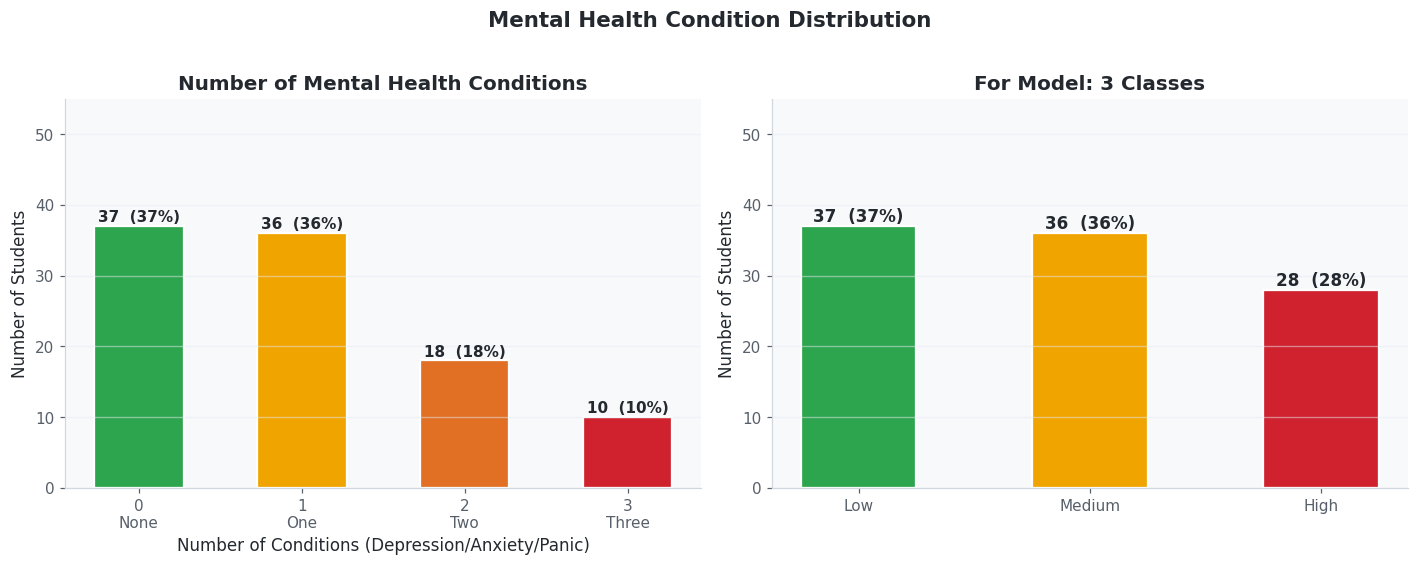

Saved → fig01_stress_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mental Health Condition Distribution', fontsize=14, fontweight='bold', y=1.02)

# Left: raw mental score (0-3)
ax = axes[0]
score_colors = {0:'#2DA44E', 1:'#F0A400', 2:'#E16F24', 3:'#CF222E'}
count_score = df['mental_score'].value_counts().sort_index()
labels_score = ['0\nNone','1\nOne','2\nTwo','3\nThree']
bars = ax.bar([labels_score[i] for i in count_score.index], count_score.values,
              color=[score_colors[i] for i in count_score.index],
              edgecolor='white', linewidth=1.5, width=0.55)
for b, v in zip(bars, count_score.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.6,
            f'{v}  ({v/len(df)*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Number of Mental Health Conditions')
ax.set_xlabel('Number of Conditions (Depression/Anxiety/Panic)')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.5)

# Right: 3-class stress level
ax = axes[1]
count3 = df['stress_3'].value_counts().sort_index()
bars2 = ax.bar([STRESS3_NAMES[i] for i in count3.index], count3.values,
               color=[STRESS3_COLORS[i] for i in count3.index],
               edgecolor='white', linewidth=1.5, width=0.5)
for b, v in zip(bars2, count3.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.6,
            f'{v}  ({v/len(df)*100:.0f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('For Model: 3 Classes')
ax.set_ylabel('Number of Students')
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('fig01_stress_distribution.png')
plt.show()
print('Saved → fig01_stress_distribution.png')


### 4.2 Демография: оқу деңгейі және зиянды әдеттер

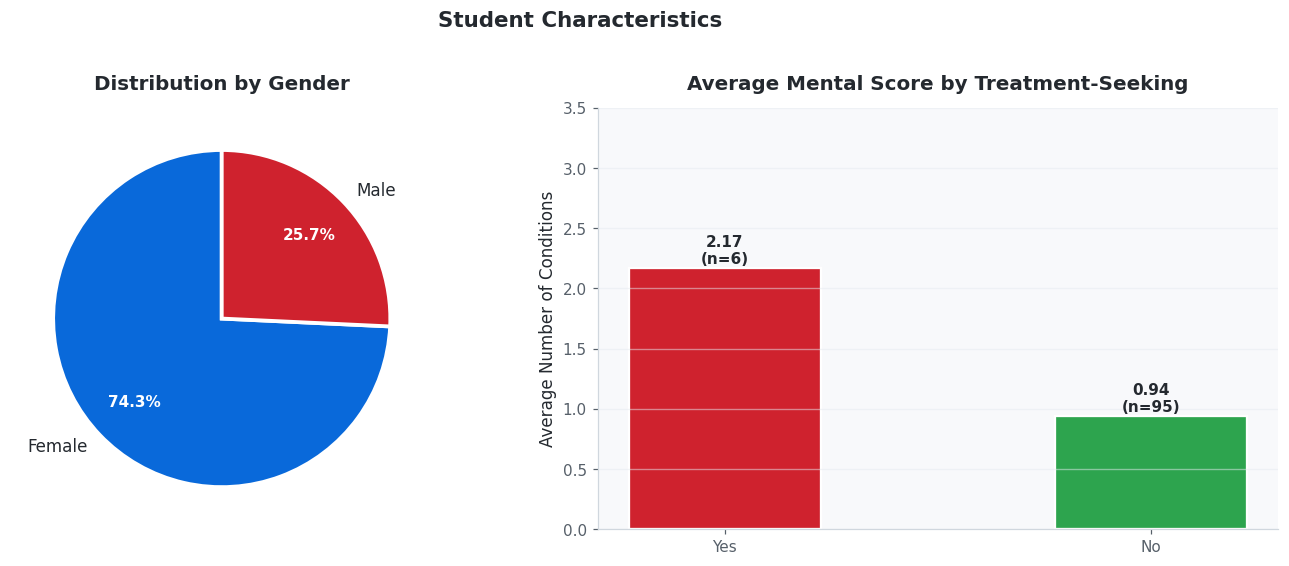

Saved → fig02_demographics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Student Characteristics', fontsize=14, fontweight='bold', y=1.02)

# Left: gender distribution
ax = axes[0]
gender_count = df['gender'].value_counts()
_, texts, autotexts = ax.pie(
    gender_count.values, labels=gender_count.index,
    autopct='%1.1f%%', colors=['#0969DA','#CF222E'],
    startangle=90, pctdistance=0.72,
    wedgeprops=dict(edgecolor='white', linewidth=2.5))
for t in texts: t.set_fontsize(11)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax.set_title('Distribution by Gender', pad=12)

# Right: average mental score by treatment-seeking
ax = axes[1]
treat_stress = df.groupby('treatment')['mental_score'].mean().sort_values(ascending=False)
treat_count  = df['treatment'].value_counts()
treat_colors = {'Yes': '#CF222E', 'No': '#2DA44E'}
bars = ax.bar(treat_stress.index, treat_stress.values,
              color=[treat_colors.get(h,'#0969DA') for h in treat_stress.index],
              edgecolor='white', linewidth=1.5, width=0.45)
for b, v, idx in zip(bars, treat_stress.values, treat_stress.index):
    n = treat_count.get(idx, 0)
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.04,
            f'{v:.2f}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Mental Score by Treatment-Seeking', pad=12)
ax.set_ylabel('Average Number of Conditions')
ax.set_ylim(0, 3.5)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('fig02_demographics.png')
plt.show()
print('Saved → fig02_demographics.png')


### 4.3 Қысым мен бәсекелестік vs стресс

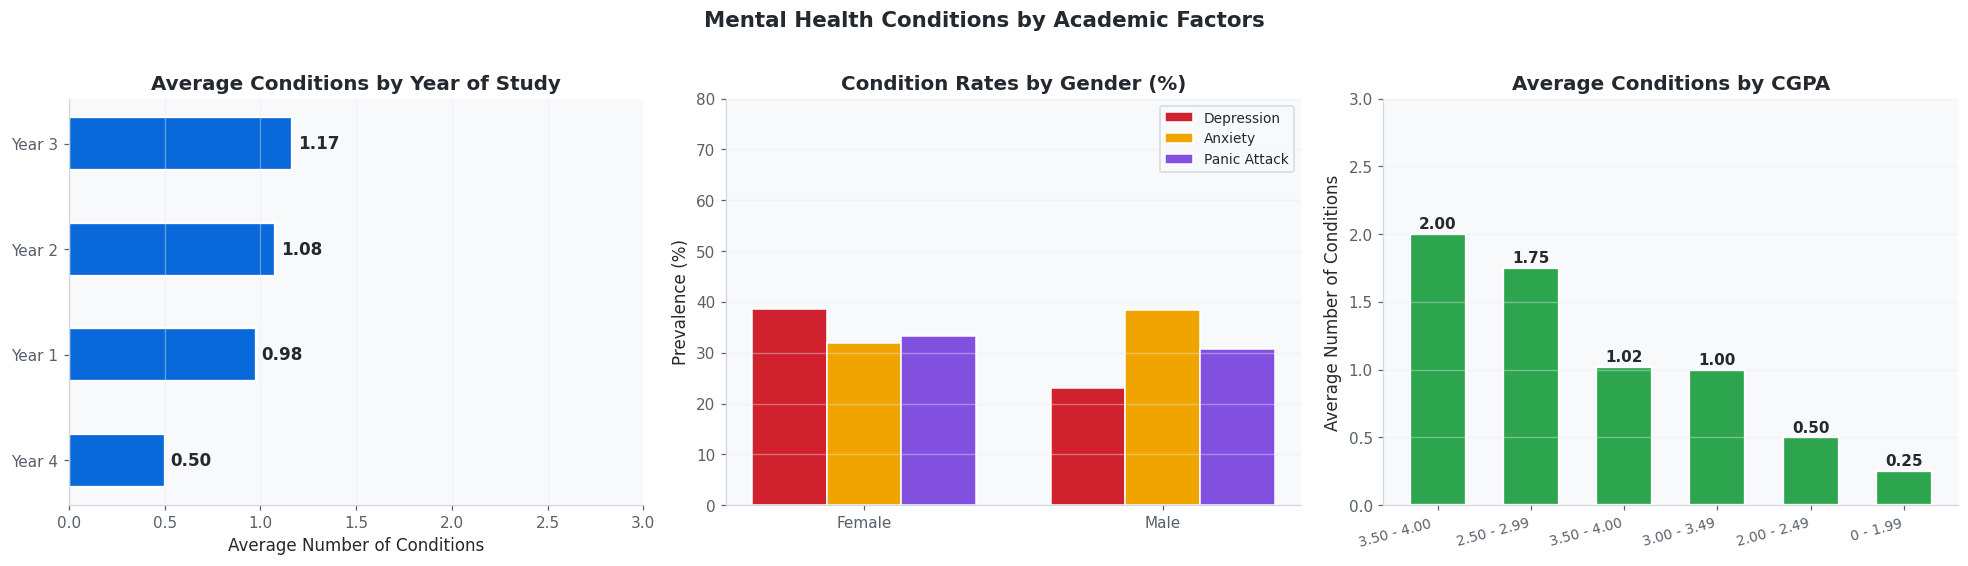

Saved → fig03_academic_factors.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mental Health Conditions by Academic Factors', fontsize=14, fontweight='bold', y=1.02)

# Left: conditions by year of study
ax = axes[0]
year_map = {'year_1':'Year 1','year_2':'Year 2','year_3':'Year 3','year_4':'Year 4'}
df['year_label'] = df['year'].map(year_map).fillna(df['year'])
year_stress = df.groupby('year_label')['mental_score'].mean().sort_values()
bars = ax.barh(year_stress.index, year_stress.values,
               color='#0969DA', edgecolor='white', linewidth=1.5, height=0.5)
for b, v in zip(bars, year_stress.values):
    ax.text(b.get_width()+0.03, b.get_y()+b.get_height()/2,
            f'{v:.2f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Average Conditions by Year of Study')
ax.set_xlabel('Average Number of Conditions')
ax.set_xlim(0, 3)
ax.grid(axis='x', alpha=0.4)

# Middle: depression rate by gender
ax = axes[1]
gender_dep = df.groupby('gender')[['dep','anx','pan']].mean() * 100
x = np.arange(len(gender_dep))
w = 0.25
ax.bar(x-w, gender_dep['dep'], w, color='#CF222E', label='Depression', edgecolor='white')
ax.bar(x,   gender_dep['anx'], w, color='#F0A400', label='Anxiety',    edgecolor='white')
ax.bar(x+w, gender_dep['pan'], w, color='#8250DF', label='Panic Attack', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(gender_dep.index)
ax.set_title('Condition Rates by Gender (%)')
ax.set_ylabel('Prevalence (%)')
ax.set_ylim(0, 80)
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Right: mental score by CGPA
ax = axes[2]
cgpa_stress = df.groupby('cgpa')['mental_score'].mean().sort_values(ascending=False)
bars3 = ax.bar(range(len(cgpa_stress)), cgpa_stress.values,
               color='#2DA44E', edgecolor='white', linewidth=1.5, width=0.6)
for b, v in zip(bars3, cgpa_stress.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.04,
            f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(cgpa_stress)))
ax.set_xticklabels(cgpa_stress.index, rotation=15, ha='right', fontsize=9)
ax.set_title('Average Conditions by CGPA')
ax.set_ylabel('Average Number of Conditions')
ax.set_ylim(0, 3)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig03_academic_factors.png')
plt.show()
print('Saved → fig03_academic_factors.png')


### 4.4 Оқу ортасы және стресспен күресу стратегиялары

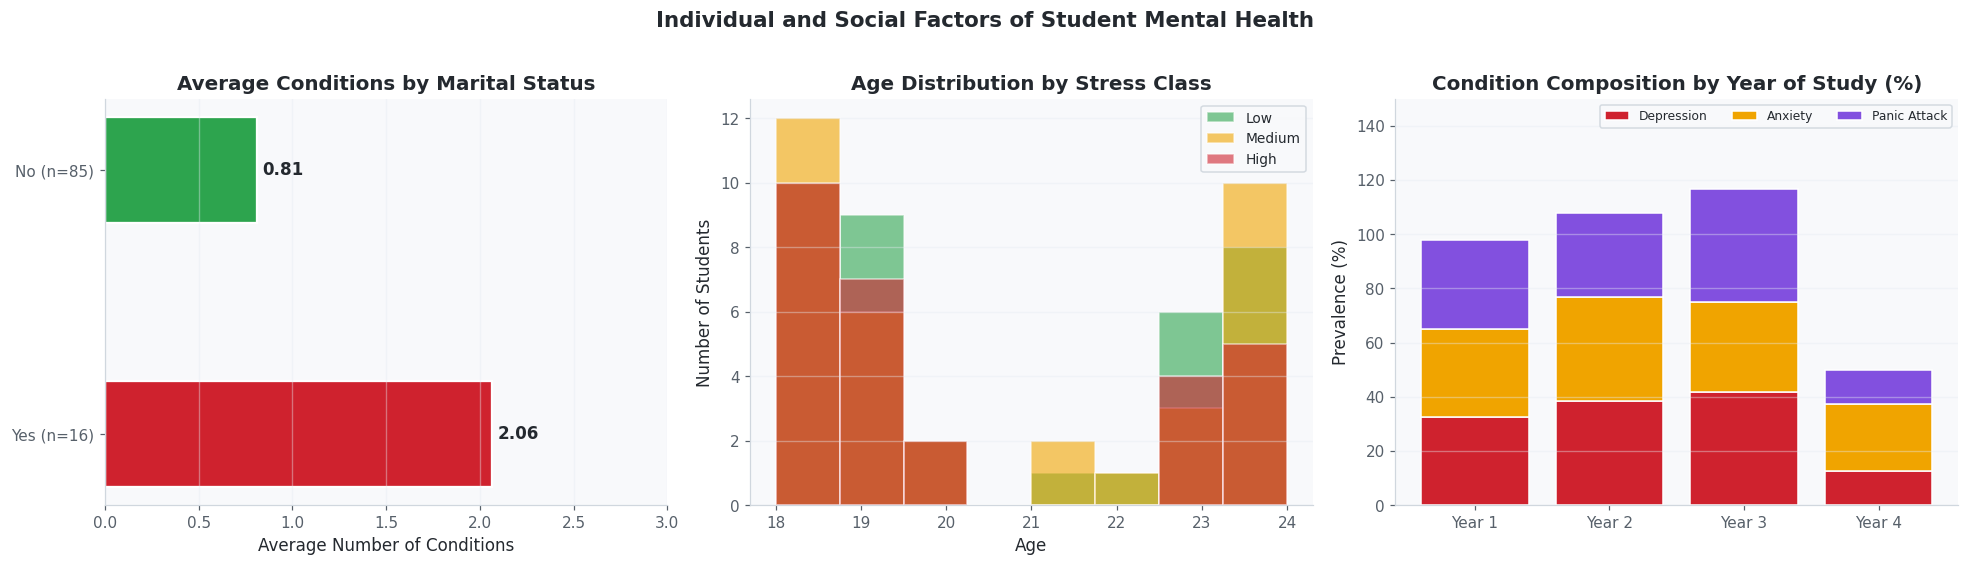

Saved → fig04_social_factors.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Individual and Social Factors of Student Mental Health',
             fontsize=14, fontweight='bold', y=1.02)

# Left: marital status vs mental score
ax = axes[0]
marital_stress = df.groupby('marital')['mental_score'].mean().sort_values(ascending=False)
marital_count  = df['marital'].value_counts()
bars = ax.barh([f'{m} (n={marital_count[m]})' for m in marital_stress.index],
               marital_stress.values,
               color=['#CF222E','#2DA44E'], edgecolor='white', linewidth=1.5, height=0.4)
for b, v in zip(bars, marital_stress.values):
    ax.text(b.get_width()+0.03, b.get_y()+b.get_height()/2,
            f'{v:.2f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Average Conditions by Marital Status')
ax.set_xlabel('Average Number of Conditions')
ax.set_xlim(0, 3)
ax.grid(axis='x', alpha=0.4)

# Middle: age distribution by stress class
ax = axes[1]
for cls, color in STRESS3_COLORS.items():
    ages = df[df['stress_3']==cls]['age']
    ax.hist(ages, bins=8, alpha=0.6, color=color, label=STRESS3_NAMES[cls], edgecolor='white')
ax.set_title('Age Distribution by Stress Class')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Students')
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Right: stacked bar — condition composition by year
ax = axes[2]
year_order = ['year_1','year_2','year_3','year_4']
year_labels = ['Year 1','Year 2','Year 3','Year 4']
dep_r = [df[df['year']==y]['dep'].mean()*100 for y in year_order]
anx_r = [df[df['year']==y]['anx'].mean()*100 for y in year_order]
pan_r = [df[df['year']==y]['pan'].mean()*100 for y in year_order]
x = np.arange(len(year_order))
ax.bar(x, dep_r, label='Depression', color='#CF222E', edgecolor='white')
ax.bar(x, anx_r, bottom=dep_r, label='Anxiety', color='#F0A400', edgecolor='white')
ax.bar(x, pan_r, bottom=[d+a for d,a in zip(dep_r,anx_r)],
       label='Panic Attack', color='#8250DF', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(year_labels)
ax.set_title('Condition Composition by Year of Study (%)')
ax.set_ylabel('Prevalence (%)')
ax.set_ylim(0, 150)
ax.legend(ncol=3, loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig04_social_factors.png')
plt.show()
print('Saved → fig04_social_factors.png')


### 4.5 Сандық белгілердің корреляциясы

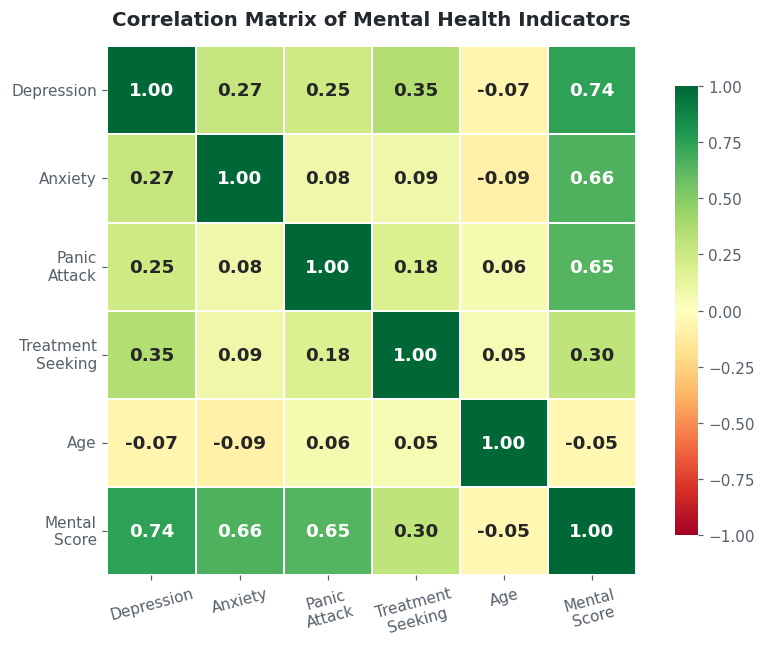

Saved → fig05_correlation.png


In [10]:
# Binary encode for correlation
corr_df = df[['dep','anx','pan','treat','age','mental_score']].copy()
corr_df.columns = ['Depression','Anxiety','Panic\nAttack','Treatment\nSeeking','Age','Mental\nScore']
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=1, linecolor='white',
            annot_kws={'size':12, 'weight':'bold'}, cbar_kws={'shrink':0.85})
ax.set_title('Correlation Matrix of Mental Health Indicators', pad=14)
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('fig05_correlation.png')
plt.show()
print('Saved → fig05_correlation.png')


---
## 5. Белгілерді дайындау

In [11]:
# ── Label Encoding ──
le_gender  = LabelEncoder(); df['gender_enc']  = le_gender.fit_transform(df['gender'])
le_course  = LabelEncoder(); df['course_enc']  = le_course.fit_transform(df['course_clean'])
le_year    = LabelEncoder(); df['year_enc']    = le_year.fit_transform(df['year'])
le_cgpa    = LabelEncoder(); df['cgpa_enc']    = le_cgpa.fit_transform(df['cgpa'])
le_marital = LabelEncoder(); df['marital_enc'] = le_marital.fit_transform(df['marital'])

# ── Feature Engineering ──
df['age_cgpa']       = df['age'] * df['cgpa_enc']
df['year_marital']   = df['year_enc'] * df['marital_enc']
df['treat_age']      = df['treat'] * df['age']
df['gender_year']    = df['gender_enc'] * df['year_enc']

FEATURES = [
    'gender_enc', 'age', 'course_enc', 'year_enc', 'cgpa_enc',
    'marital_enc', 'treat',
    'age_cgpa', 'year_marital', 'treat_age', 'gender_year'
]

print('Encodings:')
for le, name in [(le_gender,'gender'),(le_course,'course'),(le_year,'year'),
                  (le_cgpa,'cgpa'),(le_marital,'marital')]:
    print(f'  {name}: {dict(enumerate(le.classes_))}')
print(f'\nTotal features: {len(FEATURES)}')
print('  Original: 7  |  Engineered: 4')


Encodings:
  gender: {0: 'Female', 1: 'Male'}
  course: {0: 'BCS', 1: 'BIT', 2: 'Biomedical science', 3: 'Engineering', 4: 'KOE', 5: 'Other'}
  year: {0: 'year_1', 1: 'year_2', 2: 'year_3', 3: 'year_4'}
  cgpa: {0: '0 - 1.99', 1: '2.00 - 2.49', 2: '2.50 - 2.99', 3: '3.00 - 3.49', 4: '3.50 - 4.00', 5: '3.50 - 4.00 '}
  marital: {0: 'No', 1: 'Yes'}

Total features: 11
  Original: 7  |  Engineered: 4


In [12]:
# ── Bootstrap Oversampling — balancing classes ──
max_count = df['stress_3'].value_counts().max()
parts = []
for cls in df['stress_3'].unique():
    d = df[df['stress_3'] == cls]
    if len(d) < max_count:
        d = resample(d, replace=True, n_samples=max_count, random_state=42)
    parts.append(d)

df_balanced = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

print('After oversampling:')
for k, v in df_balanced['stress_3'].value_counts().sort_index().items():
    print(f'  {STRESS3_NAMES[k]}: {v}')

X = df_balanced[FEATURES].values
y = df_balanced['stress_3'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')


After oversampling:
  Low: 37
  Medium: 37
  High: 37

Train: 88 | Test: 23


---
## 6. Модельдерді оқыту

In [13]:
MODELS = {
    'Extra Trees': (
        ExtraTreesClassifier(n_estimators=500, random_state=42), False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42), False
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=500, random_state=42), False
    ),
    'SVM': (
        SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42), True
    ),
    'Voting Ensemble': (
        VotingClassifier(estimators=[
            ('et', ExtraTreesClassifier(n_estimators=300, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=300, random_state=42)),
        ], voting='soft'), False
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<22} {"Accuracy":>10} {"F1":>8} {"Precision":>10} {"Recall":>8} {"CV":>14}')
print('─' * 80)

for name, (model, scaled) in MODELS.items():
    Xtr = X_train_scaled if scaled else X_train
    Xte = X_test_scaled if scaled else X_test

    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='weighted')
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)

    results[name] = dict(
        model=model,
        predictions=predictions,
        scaled=scaled,
        accuracy=acc,
        f1=f1,
        precision=prec,
        recall=rec,
        cv_mean=cv_scores.mean(),
        cv_std=cv_scores.std()
    )

    print(f'{name:<22} {acc:>10.3f} {f1:>8.3f} {prec:>10.3f} {rec:>8.3f}  {cv_scores.mean():.3f}±{cv_scores.std():.3f}')

best_name = max(results, key=lambda k: results[k]['accuracy'])

print(f'\nBest model: {best_name}  (Accuracy={results[best_name]["accuracy"]:.1%})')

Model                    Accuracy       F1  Precision   Recall             CV
────────────────────────────────────────────────────────────────────────────────
Extra Trees                 0.478    0.473      0.475    0.478  0.601±0.057
Gradient Boosting           0.522    0.518      0.516    0.522  0.625±0.057
Random Forest               0.478    0.474      0.473    0.478  0.589±0.092
SVM                         0.565    0.521      0.540    0.565  0.487±0.102
Voting Ensemble             0.478    0.473      0.475    0.478  0.590±0.071

Best model: SVM  (Accuracy=56.5%)


### 7.1 Негізгі метрикалар

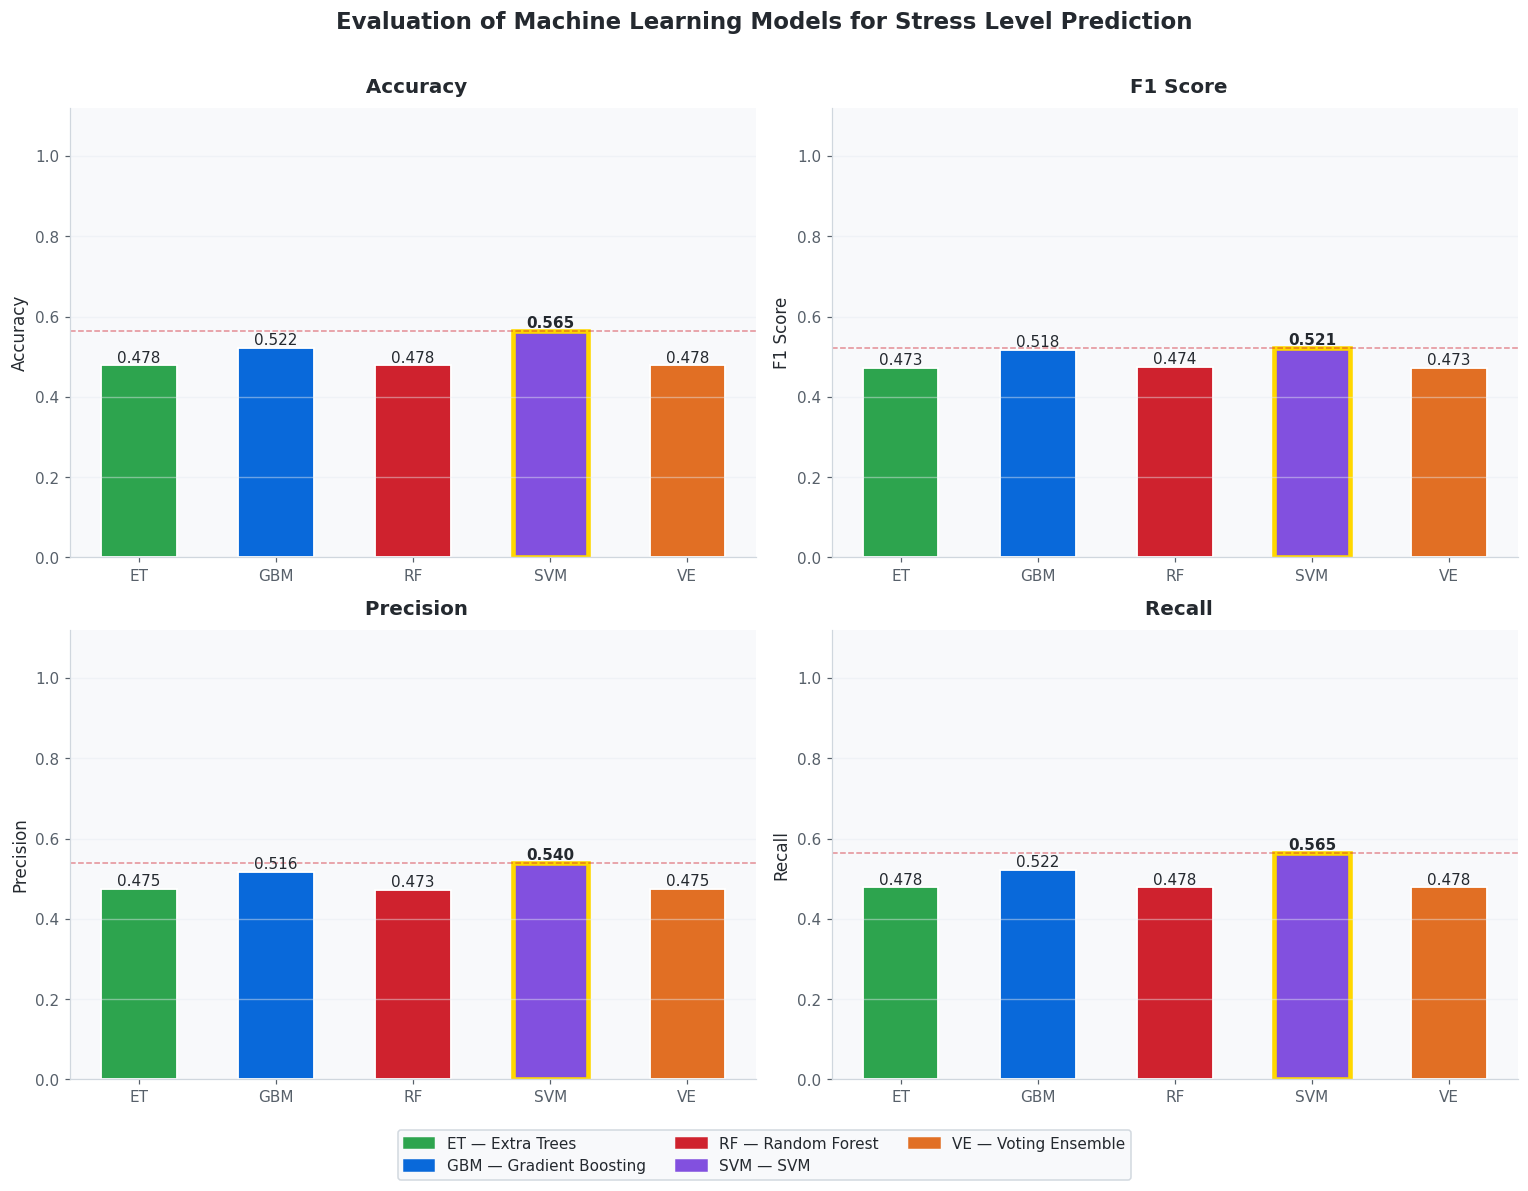

Saved → table_06_metrics.png


In [14]:
model_names = list(results.keys())
short_names = ['ET', 'GBM', 'RF', 'SVM', 'VE']

bar_colors = [MODEL_COLORS[n] for n in model_names]

metrics_config = [
    ('accuracy',  'Accuracy',  ''),
    ('f1',        'F1 Score',  ''),
    ('precision', 'Precision', ''),
    ('recall',    'Recall',    ''),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluation of Machine Learning Models for Stress Level Prediction',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (metric, label, icon) in zip(axes.flat, metrics_config):

    values = [results[n][metric] for n in model_names]
    max_val = max(values)

    edge_colors = ['#FFD700' if v == max_val else 'white' for v in values]
    line_widths = [3.0 if v == max_val else 1.2 for v in values]

    bars = ax.bar(
        short_names,
        values,
        color=bar_colors,
        edgecolor=edge_colors,
        linewidth=line_widths,
        width=0.55
    )

    for b, v in zip(bars, values):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + 0.008,
            f'{v:.3f}',
            ha='center',
            fontsize=10,
            fontweight='bold' if v == max_val else 'normal'
        )

    ax.axhline(y=max_val, color='#CF222E',
               linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{icon} {label}', pad=10)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.12)
    ax.grid(axis='y', alpha=0.45)

legend_elements = [
    mpatches.Patch(color=MODEL_COLORS[n], label=f'{s} — {n}')
    for n, s in zip(model_names, short_names)
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
    framealpha=0.95
)

plt.tight_layout()
plt.savefig('table_06_metrics.png')
plt.show()

print('Saved → table_06_metrics.png')

### 7.2 Cross-Validation (5-fold)

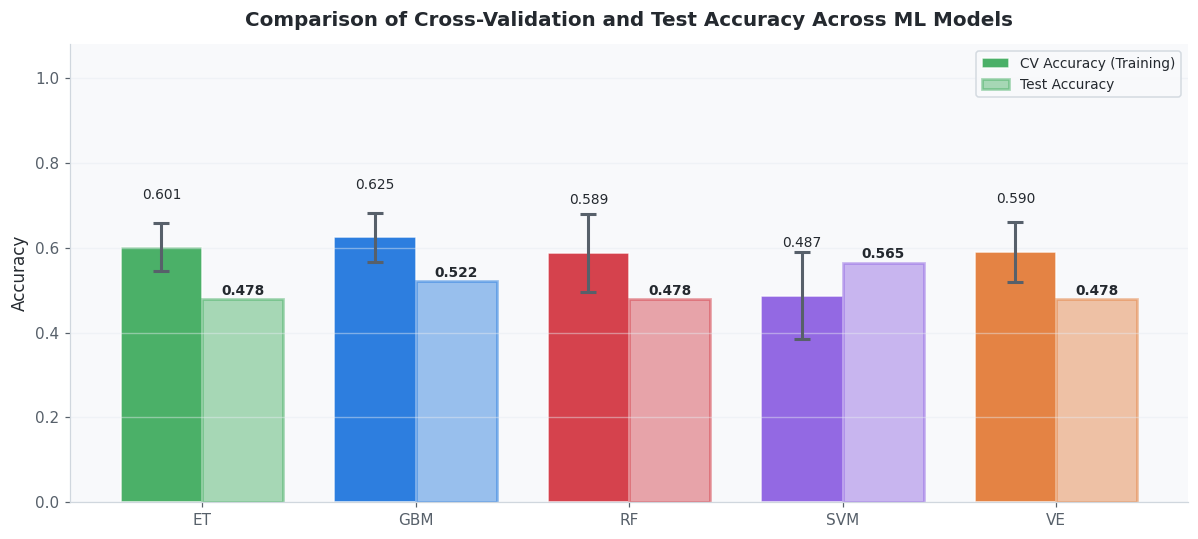

Saved → table_07_cv_vs_test.png


In [15]:
cv_mean  = [results[n]['cv_mean'] for n in model_names]
cv_std   = [results[n]['cv_std']  for n in model_names]
test_acc = [results[n]['accuracy'] for n in model_names]

x = np.arange(len(model_names))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))

# Training CV Accuracy with error bars
ax.bar(
    x - w/2, cv_mean, w,
    color=bar_colors, alpha=0.85, edgecolor='white',
    yerr=cv_std, capsize=5,
    error_kw={'elinewidth':2, 'ecolor':'#57606A', 'capthick':2},
    label='CV Accuracy (Training)'
)

# Test Accuracy
ax.bar(
    x + w/2, test_acc, w,
    color=bar_colors, alpha=0.4,
    edgecolor=bar_colors, linewidth=1.8,
    label='Test Accuracy'
)

# Add values above bars
for i, (cv, test) in enumerate(zip(cv_mean, test_acc)):
    ax.text(i - w/2, cv + max(cv_std) + 0.012, f'{cv:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.08)
ax.set_title('Comparison of Cross-Validation and Test Accuracy Across ML Models', pad=12)
ax.legend()
ax.grid(axis='y', alpha=0.45)

plt.tight_layout()
plt.savefig('table_07_cv_vs_test.png')
plt.show()

print('Saved → table_07_cv_vs_test.png')

### 7.3 Қателік матрицалары — барлық модельдер

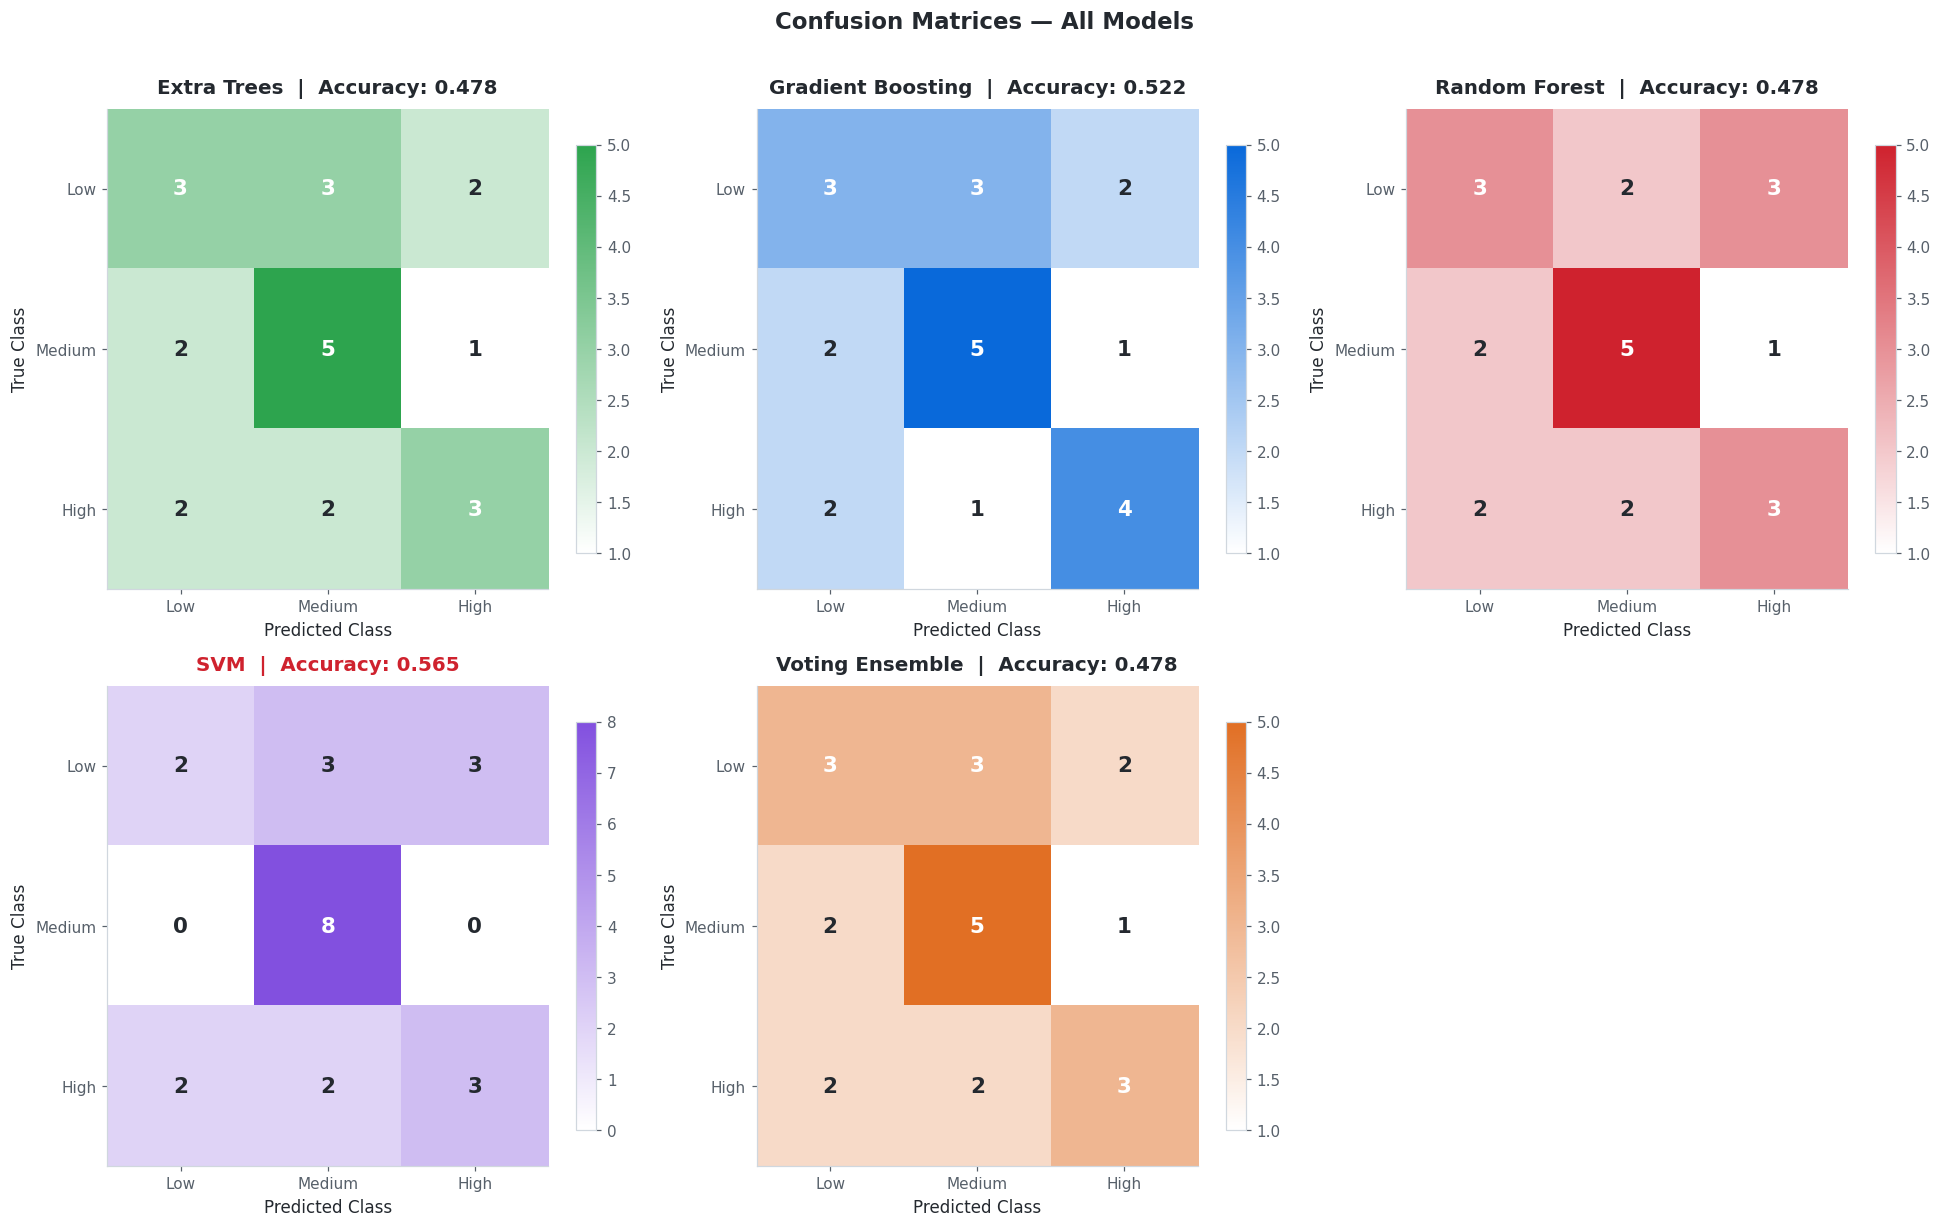

Saved → table_08_confusion_matrices.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes[1][2].set_visible(False)  # Hide the empty subplot
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)

plot_axes = [axes[0][0], axes[0][1], axes[0][2], axes[1][0], axes[1][1]]
cm_labels = [STRESS3_NAMES[i] for i in range(3)]

for idx, model_name in enumerate(model_names):
    ax = plot_axes[idx]
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    cmap = LinearSegmentedColormap.from_list('c', ['#FFFFFF', MODEL_COLORS[model_name]], N=256)
    im = ax.imshow(cm, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)

    for i in range(3):
        for j in range(3):
            color = 'white' if cm[i, j] > cm.max()*0.55 else '#24292F'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(cm_labels)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(cm_labels)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')

    highlight = ''  # optional symbol for best model
    title_color = '#CF222E' if model_name == best_name else '#24292F'
    ax.set_title(f'{model_name}{highlight}  |  Accuracy: {results[model_name]["accuracy"]:.3f}',
                 color=title_color, pad=10)

plt.tight_layout()
plt.savefig('table_08_confusion_matrices.png')
plt.show()
print('Saved → table_08_confusion_matrices.png')

### 8.1 Толық есеп және Radar диаграммасы

In [17]:
print(f'Full Report — {best_name}')
print('='*55)
print(classification_report(
    y_test, results[best_name]['predictions'],
    target_names=['Low (1–2)', 'Medium (3)', 'High (4–5)']
))

Full Report — SVM
              precision    recall  f1-score   support

   Low (1–2)       0.50      0.25      0.33         8
  Medium (3)       0.62      1.00      0.76         8
  High (4–5)       0.50      0.43      0.46         7

    accuracy                           0.57        23
   macro avg       0.54      0.56      0.52        23
weighted avg       0.54      0.57      0.52        23



### 8.2 Белгілердің маңыздылығы (Extra Trees)

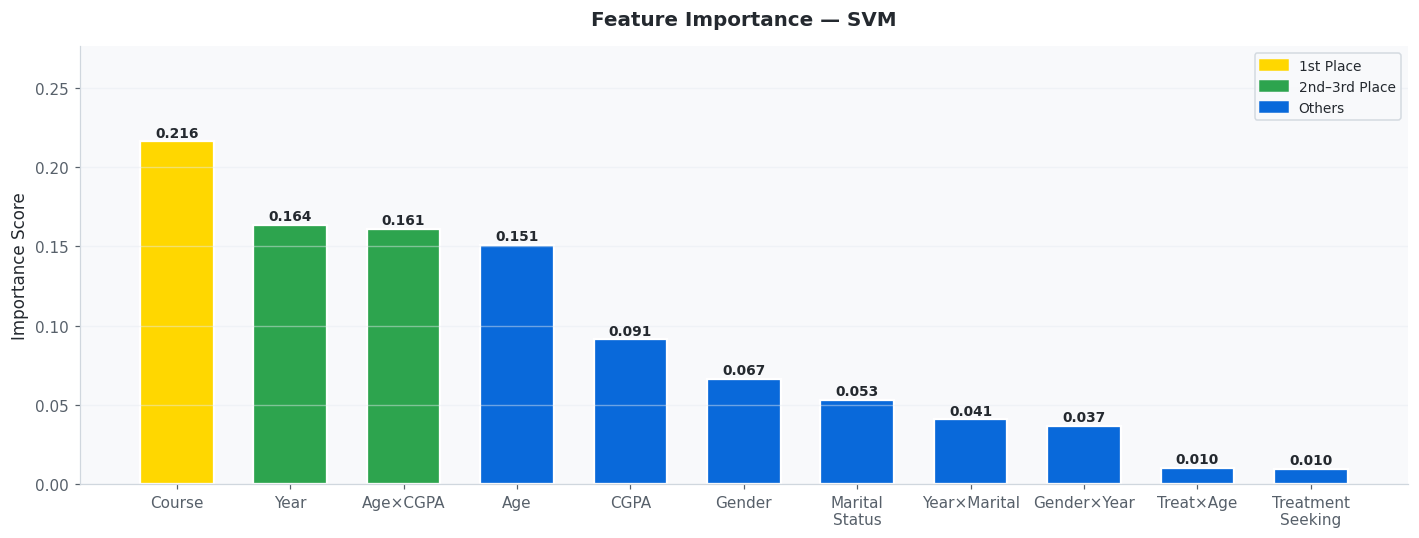

Saved → fig10_feature_importance.png


In [18]:
et_model = results['Extra Trees']['model']
feature_names = [
    'Gender', 'Age', 'Course', 'Year', 'CGPA',
    'Marital\nStatus', 'Treatment\nSeeking',
    'Age×CGPA', 'Year×Marital', 'Treat×Age', 'Gender×Year'
]
importance = et_model.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_values = importance[sorted_idx]

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#FFD700' if i==0 else '#2DA44E' if i<=2 else '#0969DA'
          for i in range(len(sorted_values))]
bars = ax.bar(sorted_names, sorted_values, color=colors,
              edgecolor='white', linewidth=1.5, width=0.65)
for b, v in zip(bars, sorted_values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title(f'Feature Importance — {best_name}', pad=14)
ax.set_ylabel('Importance Score')
ax.set_ylim(0, sorted_values[0]+0.06)
ax.grid(axis='y', alpha=0.45)
ax.legend(handles=[
    mpatches.Patch(color='#FFD700', label='1st Place'),
    mpatches.Patch(color='#2DA44E', label='2nd–3rd Place'),
    mpatches.Patch(color='#0969DA', label='Others'),
])
plt.tight_layout()
plt.savefig('fig10_feature_importance.png')
plt.show()
print('Saved → fig10_feature_importance.png')


---
## 9. Модельді сақтау

In [19]:
import joblib
import json
import numpy as np

# ── Save trained model and scaler ──
joblib.dump(results[best_name]['model'], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# ── Save encoder and metadata info ──
encoder_info = {
    'best_name':       best_name,
    'dataset':         'Student Mental Health',
    'task':            '3 classes: 0=Low (0 conditions), 1=Medium (1 condition), 2=High (2-3 conditions)',
    'features':        FEATURES,
    'gender_classes':  le_gender.classes_.tolist(),
    'course_classes':  le_course.classes_.tolist(),
    'year_classes':    le_year.classes_.tolist(),
    'cgpa_classes':    le_cgpa.classes_.tolist(),
    'marital_classes': le_marital.classes_.tolist(),
    'metrics': {
        'accuracy':  round(results[best_name]['accuracy'],  4),
        'f1':        round(results[best_name]['f1'],        4),
        'precision': round(results[best_name]['precision'], 4),
        'recall':    round(results[best_name]['recall'],    4),
    }
}

with open('encoder_info.json', 'w', encoding='utf-8') as f:
    json.dump(encoder_info, f, ensure_ascii=False, indent=2)

# ── Test prediction ──
# Sample: Female=0, Age=20, BCS=0, year_1=0, CGPA 3.50-4.00=3, Not married=0, No treatment=0
# + engineered: age_cgpa=60, year_marital=0, treat_age=0, gender_year=0
loaded_model = joblib.load('best_model.pkl')
sample = np.array([[0, 20, 0, 0, 3, 0, 0,  60, 0, 0, 0]])
prediction = loaded_model.predict(sample)
label = STRESS3_NAMES[prediction[0]]

print('Saved files:')
print('   best_model.pkl    — trained model')
print('   scaler.pkl        — scaler')
print('   encoder_info.json — encoders & mappings')
print(f'\nTest prediction: {label} (class {prediction[0]})')
print(f'\nBest model: {best_name}')
print(f'   Accuracy  = {results[best_name]["accuracy"]:.3f}')
print(f'   F1 Score  = {results[best_name]["f1"]:.3f}')
print(f'   Precision = {results[best_name]["precision"]:.3f}')
print(f'   Recall    = {results[best_name]["recall"]:.3f}')
print('\nAnalysis complete! All files saved.')


Saved files:
   best_model.pkl    — trained model
   scaler.pkl        — scaler
   encoder_info.json — encoders & mappings

Test prediction: Low (class 0)

Best model: SVM
   Accuracy  = 0.565
   F1 Score  = 0.521
   Precision = 0.540
   Recall    = 0.565

Analysis complete! All files saved.
